In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

scaler = MinMaxScaler()

normalized_data = scaler.fit_transform(data)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=data.columns
)

print(normalized_df)

      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

scaler = StandardScaler()

standardized_data = scaler.fit_transform(data)

standardized_df = pd.DataFrame(
    standardized_data,
    columns=data.columns
)

print(standardized_df)

          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue']
})

one_hot = pd.get_dummies(df, columns=['Color'])

print(one_hot)

   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


In [ ]:
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler
)

tips = sns.load_dataset("tips")

print(tips.head())

numeric_cols = tips.select_dtypes(
    include=['float64', 'int64']
).columns

# Normalization
minmax = MinMaxScaler()

tips_normalized = tips.copy()

tips_normalized[numeric_cols] = minmax.fit_transform(
    tips[numeric_cols]
)

print(tips_normalized.head())

# Standardization
standard = StandardScaler()

tips_standardized = tips.copy()

tips_standardized[numeric_cols] = standard.fit_transform(
    tips[numeric_cols]
)

print(tips_standardized.head())

# One Hot Encoding
tips_onehot = pd.get_dummies(
    tips,
    columns=['sex', 'smoker', 'day', 'time']
)

print(tips_onehot.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  Sun  Dinner  0.453383
3    0.438315  0.225754    Male     No  Sun  Dinner -0.600193
4    0.540745  0.4

In [ ]:
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

tips = sns.load_dataset("tips")

numeric_data = tips.select_dtypes(
    include=['float64', 'int64']
)

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    numeric_data
)

pca = PCA(n_components=2)

pca_result = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame(
    pca_result,
    columns=['PC1', 'PC2']
)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(pca_df.head())

Explained Variance Ratio:
[0.72627656 0.1730423 ]
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


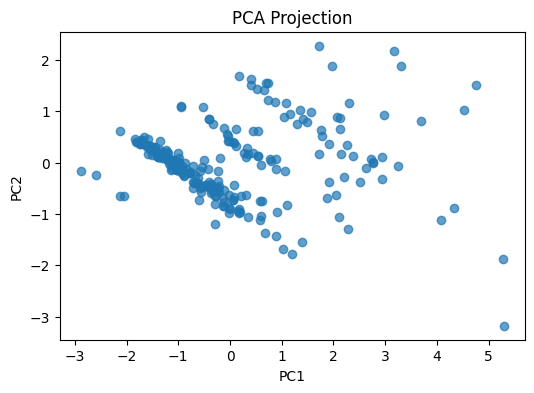

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Projection")

plt.show()

        LD1       LD2  target
0  8.061800 -0.300421       0
1  7.128688  0.786660       0
2  7.489828  0.265384       0
3  6.813201  0.670631       0
4  8.132309 -0.514463       0


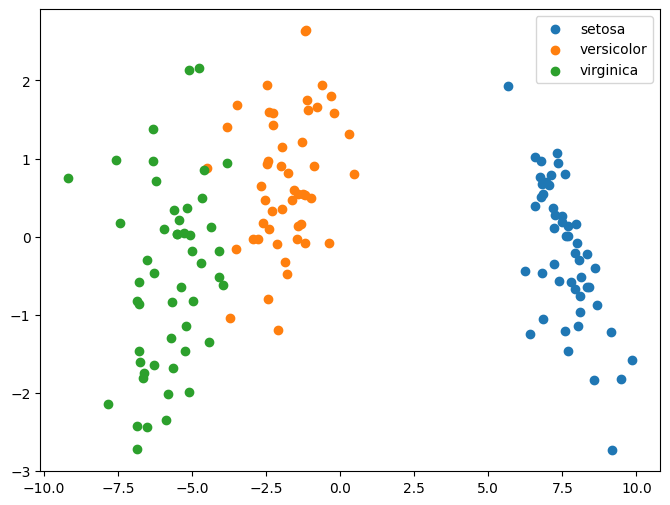

In [ ]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(X, y)

lda_df = pd.DataFrame(
    X_lda,
    columns=['LD1', 'LD2']
)

lda_df['target'] = y

print(lda_df.head())

plt.figure(figsize=(8,6))

for label in [0,1,2]:
    plt.scatter(
        lda_df[lda_df['target']==label]['LD1'],
        lda_df[lda_df['target']==label]['LD2'],
        label=iris.target_names[label]
    )

plt.legend()
plt.show()

In [ ]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE1', 'TSNE2']
)

tsne_df['target'] = y

print(tsne_df.head())

       TSNE1     TSNE2  target
0 -24.284670 -0.196069       0
1 -21.731905  0.653882       0
2 -21.776773 -0.433848       0
3 -21.413086 -0.141203       0
4 -24.284908 -0.606254       0
